In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.pyplot import figure
from scipy import stats

In [ ]:
baseline_values = pd.read_csv('/content/drive/MyDrive/AB-test/data/Final Project Baseline Values.csv', header=None)

In [ ]:
for ind, value in enumerate(baseline_values[0].values):
    print(value, np.array(baseline_values)[ind, 1])

Unique cookies to view course overview page per day: 40000.0
Unique cookies to click "Start free trial" per day: 3200.0
Enrollments per day: 660.0
Click-through-probability on "Start free trial": 0.08
Probability of enrolling, given click: 0.20625
Probability of payment, given enroll: 0.53
Probability of payment, given click 0.1093125


## Understanding the baseline data

In [ ]:
n_visits = np.array(baseline_values)[0, 1]
n_clicks = np.array(baseline_values)[1, 1]
n_enroll = np.array(baseline_values)[2, 1]

In [ ]:
ctp = n_clicks/n_visits
assert round(ctp, 2) == np.array(baseline_values)[3, 1]

In [ ]:
p_enroll_click = n_enroll/n_clicks
assert round(p_enroll_click, 5) == np.array(baseline_values)[4, 1]

In [ ]:
n_payments = np.array(baseline_values)[5, 1]*n_enroll
p_pay_click = n_payments/n_clicks
assert round(p_pay_click, 7) == np.array(baseline_values)[6, 1]

## Metric choice

### Invariant metrics
* Number of cookies
* Number of clicks
* Click through probability

### Evaluation metrics
* Number of enrollments/user-ids
* Gross conversion
* Net Conversion
* Retention


## Variability

Calculating analytic standard error for experiment size estimate. The sample size is 5000 cookies. This amounts to:

* Number of clicks = (click through probability) x (# cookies) = 0.08 * 5000 = 400
* Number of enrollments/user-ids = (gross conversion) x (# clicks) = 0.20625 * 400 = 87.5

In [ ]:
columns = ['Cookies', 'Clicks', 'Enrollments', 'CTP', 'Gross_conversion', 'Retention', 'Net_conversion']
baseline_df = pd.DataFrame()
baseline_df['Metrics'] = columns
baseline_df['Baseline_values'] = baseline_values[[1]]
baseline_df

,Metrics,Baseline_values
0,Cookies,40000.000000
1,Clicks,3200.000000
2,Enrollments,660.000000
3,CTP,0.080000
4,Gross_conversion,0.206250
5,Retention,0.530000
6,Net_conversion,0.109313


In [ ]:
inv_metric_probs = ['Cookies', 'Clicks', 'CTP']
eval_metric_probs = ['Enrollments', 'Gross_conversion', 'Retention', 'Net_conversion']
rates = ['CTP', 'Gross_conversion', 'Retention', 'Net_conversion']

In [ ]:
std_dev = {}
std_dev['Cookies'] = None
std_dev['Clicks'] = None
std_dev['Enrollments'] = None

In [ ]:
n_sample = 5000
for metric in inv_metric_probs + eval_metric_probs:
    val = baseline_df.loc[baseline_df['Metrics'] == metric]['Baseline_values'].values[0]
    if metric in rates:
        std_dev[metric] = round(np.sqrt(val*(1 - val)), 4)
std_dev

{'Cookies': None,
 'Clicks': None,
 'Enrollments': None,
 'CTP': 0.2713,
 'Gross_conversion': 0.4046,
 'Retention': 0.4991,
 'Net_conversion': 0.312}

In [ ]:
std_dev_df = pd.DataFrame({'Standard_deviation': std_dev}).reset_index()
std_dev_df = std_dev_df.rename(columns = {'index': 'Metrics'})
std_dev_df

,Metrics,Standard_deviation
0,Cookies,NaN
1,Clicks,NaN
2,Enrollments,NaN
3,CTP,0.2713
4,Gross_conversion,0.4046
5,Retention,0.4991
6,Net_conversion,0.3120


In [ ]:
metrics_df = pd.merge(baseline_df, std_dev_df, on = 'Metrics')
metrics_df

,Metrics,Baseline_values,Standard_deviation
0,Cookies,40000.000000,NaN
1,Clicks,3200.000000,NaN
2,Enrollments,660.000000,NaN
3,CTP,0.080000,0.2713
4,Gross_conversion,0.206250,0.4046
5,Retention,0.530000,0.4991
6,Net_conversion,0.109313,0.3120


In [ ]:
std_err = {
 'Cookies': None,
 'Clicks': None,
 'Enrollments': None
  }

In [ ]:
# scaling num-clicks and num-enrollments for a sample size of 5000 cookies.
n_cookies = n_sample
n_clicks = ctp*n_cookies
gross_conversion = metrics_df[metrics_df['Metrics'] == 'Gross_conversion']['Baseline_values'].values[0]
n_enroll = gross_conversion*n_clicks

In [ ]:
scaled_sample_size = {
    'CTP': n_cookies,
    'Gross_conversion': n_clicks,
    'Retention': n_enroll,
    'Net_conversion': n_clicks,
    }

for metric in rates:
    val = metrics_df[metrics_df['Metrics'] == metric]['Standard_deviation'].values[0]/np.sqrt(scaled_sample_size[metric])
    std_err[metric] = round(val, 4)
std_err

{'Cookies': None,
 'Clicks': None,
 'Enrollments': None,
 'CTP': 0.0038,
 'Gross_conversion': 0.0202,
 'Retention': 0.0549,
 'Net_conversion': 0.0156}

In [ ]:
std_err_df = pd.DataFrame({'Standard_error': std_err}).reset_index()
std_err_df = std_err_df.rename(columns = {'index': 'Metrics'})
metrics_df = pd.merge(metrics_df, std_err_df, on = 'Metrics')
metrics_df

,Metrics,Baseline_values,Standard_deviation,Standard_error
0,Cookies,40000.000000,NaN,NaN
1,Clicks,3200.000000,NaN,NaN
2,Enrollments,660.000000,NaN,NaN
3,CTP,0.080000,0.2713,0.0038
4,Gross_conversion,0.206250,0.4046,0.0202
5,Retention,0.530000,0.4991,0.0549
6,Net_conversion,0.109313,0.3120,0.0156


### 95% Confidence Interval

In [ ]:
margin_of_error = {
    'Cookies': None,
    'Clicks': None,
    'Enrollments': None,
}

alpha = 0.05
z_alpha = stats.norm.ppf(1 - alpha/2)
for metric in rates:
    z_score = z_alpha*std_err[metric]
    margin_of_error[metric] = round(z_score, 4)
margin_of_error

{'Cookies': None,
 'Clicks': None,
 'Enrollments': None,
 'CTP': 0.0074,
 'Gross_conversion': 0.0396,
 'Retention': 0.1076,
 'Net_conversion': 0.0306}

In [ ]:
confidence_interval = {
    'Cookies': None,
    'Clicks': None,
    'Enrollments': None,
    }
for metric in rates:
    val = baseline_df.loc[baseline_df['Metrics'] == metric]['Baseline_values'].values[0]
    confidence_interval[metric] = (round(val - margin_of_error[metric], 4), round(val + margin_of_error[metric], 4))
confidence_interval

{'Cookies': None,
 'Clicks': None,
 'Enrollments': None,
 'CTP': (0.0726, 0.0874),
 'Gross_conversion': (0.1666, 0.2458),
 'Retention': (0.4224, 0.6376),
 'Net_conversion': (0.0787, 0.1399)}

In [ ]:
variability_df = pd.DataFrame({'Confidence_interval': confidence_interval}).reset_index()
variability_df = variability_df.rename(columns = {'index': 'Metrics'})
metrics_df = pd.merge(metrics_df, variability_df, on = 'Metrics')
metrics_df

,Metrics,Baseline_values,Standard_deviation,Standard_error,Confidence_interval
0,Cookies,40000.000000,NaN,NaN,None
1,Clicks,3200.000000,NaN,NaN,None
2,Enrollments,660.000000,NaN,NaN,None
3,CTP,0.080000,0.2713,0.0038,"(0.0726, 0.0874)"
4,Gross_conversion,0.206250,0.4046,0.0202,"(0.1666, 0.2458)"
5,Retention,0.530000,0.4991,0.0549,"(0.4224, 0.6376)"
6,Net_conversion,0.109313,0.3120,0.0156,"(0.0787, 0.1399)"


In [ ]:
min_diff = {'Cookies': 3000,
 'Clicks': 240,
 'CTP': 0.01,
 'Enrollments': 50,
 'Gross_conversion': 0.01,
 'Net_conversion': 0.0075,
 'Retention': 0.01}

In [ ]:
min_diff_df = pd.DataFrame({'d_min': min_diff}).reset_index()
min_diff_df = min_diff_df.rename(columns = {'index': 'Metrics'})
metrics_df = pd.merge(metrics_df, min_diff_df, on = 'Metrics')
metrics_df

,Metrics,Baseline_values,Standard_deviation,Standard_error,Confidence_interval,d_min
0,Cookies,40000.000000,NaN,NaN,None,3000.0000
1,Clicks,3200.000000,NaN,NaN,None,240.0000
2,Enrollments,660.000000,NaN,NaN,None,50.0000
3,CTP,0.080000,0.2713,0.0038,"(0.0726, 0.0874)",0.0100
4,Gross_conversion,0.206250,0.4046,0.0202,"(0.1666, 0.2458)",0.0100
5,Retention,0.530000,0.4991,0.0549,"(0.4224, 0.6376)",0.0100
6,Net_conversion,0.109313,0.3120,0.0156,"(0.0787, 0.1399)",0.0075


## Sizing

Calculating experiment sizes for evaluation metrics using the formula:

$N = \frac{2\sigma^2 (z_{1 - \alpha/2} + z_{1 - \beta})^2}{\delta^2}$

where:

* $\sigma$ = standard deviation
* $\alpha$ = significance level
* $1 - \beta$ = power
* $\delta$ = minimum detectable effect

In [ ]:
def min_sample_size(std_dev, d_min, alpha=0.05, beta=0.2):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(1 - beta)

    return 2*(std_dev**2)*(z_alpha + z_beta)**2/d_min**2

In [ ]:
min_samples = {
    'Cookies': None,
    'Clicks': None,
    'Enrollments': None,
  }
for metric in rates:
    if metric != 'CTP':
        min_samples[metric] = round(min_sample_size(std_dev[metric], min_diff[metric]), 4)
min_samples

{'Cookies': None,
 'Clicks': None,
 'Enrollments': None,
 'Gross_conversion': 25697.4143,
 'Retention': 39103.246,
 'Net_conversion': 27165.9146}

In [ ]:
n_cookies_baseline = metrics_df[metrics_df['Metrics'] == 'Cookies']['Baseline_values'].values[0]
n_clicks_baseline = metrics_df[metrics_df['Metrics'] == 'Clicks']['Baseline_values'].values[0]
n_enroll_baseline = metrics_df[metrics_df['Metrics'] == 'Enrollments']['Baseline_values'].values[0]

In [ ]:
n_pageviews_conversion_factors = {
    'Cookies': 1,
    'Clicks': n_cookies_baseline/n_clicks_baseline,
    'CTP': n_cookies_baseline/n_clicks_baseline,
    'Enrollments': n_cookies_baseline/n_enroll_baseline,
    'Gross_conversion': n_cookies_baseline/n_clicks_baseline,
    'Net_conversion': n_cookies_baseline/n_clicks_baseline,
    'Retention': n_cookies_baseline/n_enroll_baseline
    }

In [ ]:
n_pageviews = {
    'Cookies': None,
    'Clicks': None,
    'Enrollments': None,
    }
for key, value in min_samples.items():
    if value:
        n_pageviews[key] = 2*int(value*n_pageviews_conversion_factors[key])
n_pageviews

{'Cookies': None,
 'Clicks': None,
 'Enrollments': None,
 'Gross_conversion': 642434,
 'Retention': 4739786,
 'Net_conversion': 679146}

In [ ]:
n_pageviews_df = pd.DataFrame({'n_pageviews': n_pageviews}).reset_index()
n_pageviews_df = n_pageviews_df.rename(columns = {'index': 'Metrics'})
metrics_df = pd.merge(metrics_df, n_pageviews_df, on = 'Metrics')
metrics_df

,Metrics,Baseline_values,Standard_deviation,Standard_error,Confidence_interval,d_min,n_pageviews
0,Cookies,40000.000000,NaN,NaN,None,3000.0000,NaN
1,Clicks,3200.000000,NaN,NaN,None,240.0000,NaN
2,Enrollments,660.000000,NaN,NaN,None,50.0000,NaN
3,Gross_conversion,0.206250,0.4046,0.0202,"(0.1666, 0.2458)",0.0100,642434.0
4,Retention,0.530000,0.4991,0.0549,"(0.4224, 0.6376)",0.0100,4739786.0
5,Net_conversion,0.109313,0.3120,0.0156,"(0.0787, 0.1399)",0.0075,679146.0


## Exposure vs. Duration

Let's use a criteria for a 30 days maximum duration of the experiment. This window is wide enough to include users who start the free trial, enter their credit card information and have 14 days to finish a course without making a payment.

In [ ]:
min_days = {}
for metric in rates:
    if metric != 'CTP':
        min_days[metric] = n_pageviews[metric]//n_cookies_baseline
min_days

{'Gross_conversion': 16.0, 'Retention': 118.0, 'Net_conversion': 16.0}

#### Recommendation

Increase d_min for retention from 0.01 to 0.02 so that duration of experiment can be 30 days.

## Analysis

### Observations from EDA:
* The number of data points for pageviews and clicks is about 30 each whereas for enrollments and payments is 23.
* The number of pageviews and clicks for experiment and control seem to be the same. This makes sense since the change on the Udacity website occurs after users click on free trial.
* From the plots of number of enrollments vs. date, and histogram of number of enrollments, we can qualitatively notice that the number of enrollments is higher for control compared to the experiment.
* The number of payments seems to be comparable between experiment and control.

### Takeaways:
The hypothesis of the experiment was:

"The hypothesis was that this might set clearer expectations for students upfront, thus reducing the number of frustrated students who left the free trial because they didn't have enough time—without significantly reducing the number of students to continue past the free trial and eventually complete the course. If this hypothesis held true, Udacity could improve the overall student experience and improve coaches' capacity to support students who are likely to complete the course."

Since the number of enrollments decreased for the experiment group, this suggests that users who felt they could not spend more than 5 hours a week did not enroll. In the control group however, more users enrolled because they did not see the recommendation of spending more than 5 hours a week. At the same time, the number of payments stayed the same for both experiment and control suggesting that more users in the control group left the free trial because they didn't have enough time. Therefore, the goal of reducing the number of frustrated students who drop out was accomplished in this experiment.

For the second hypothesis - "without significantly reducing the number of students to continue past the free trial and eventually complete the course" - data about how many users finished the course during the 14 day free trial period is required but not provided. A recommendation would be to track the number of user-ids who reached the end of the course including those who remained enrolled past the 14 day period and paid.

### Next step:

Perform a quantitative analysis to establish these observations.

In [ ]:
experiment = pd.read_csv('/content/drive/MyDrive/AB-test/data/Final Project Results - Experiment.csv')
control = pd.read_csv('/content/drive/MyDrive/AB-test/data/Final Project Results - Control.csv')

In [ ]:
experiment.head()

,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7716,686,105.0,34.0
1,"Sun, Oct 12",9288,785,116.0,91.0
2,"Mon, Oct 13",10480,884,145.0,79.0
3,"Tue, Oct 14",9867,827,138.0,92.0
4,"Wed, Oct 15",9793,832,140.0,94.0


In [ ]:
control.head()

,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7723,687,134.0,70.0
1,"Sun, Oct 12",9102,779,147.0,70.0
2,"Mon, Oct 13",10511,909,167.0,95.0
3,"Tue, Oct 14",9871,836,156.0,105.0
4,"Wed, Oct 15",10014,837,163.0,64.0


In [ ]:
experiment_dates = pd.to_datetime(experiment['Date'], format='%a, %b %d', errors='coerce').values
control_dates = pd.to_datetime(control['Date'], format='%a, %b %d', errors='coerce').values
date_diff = experiment_dates - control_dates
date_diff = [date.astype('timedelta64[D]')/np.timedelta64(1, 'D') for date in date_diff]
print('Do all dates in experiment and control match?', all(val == 0.0 for val in date_diff))

Do all dates in experiment and control match? True


In [ ]:
def compare_experiment_and_control(y_col):
  plt.plot([ind for ind, _ in enumerate(experiment['Date'])], experiment[y_col], label = 'Experiment')
  plt.plot([ind for ind, _ in enumerate(control['Date'])], control[y_col], label = 'Control')
  plt.xlabel('Date')
  plt.ylabel(y_col)
  plt.legend()

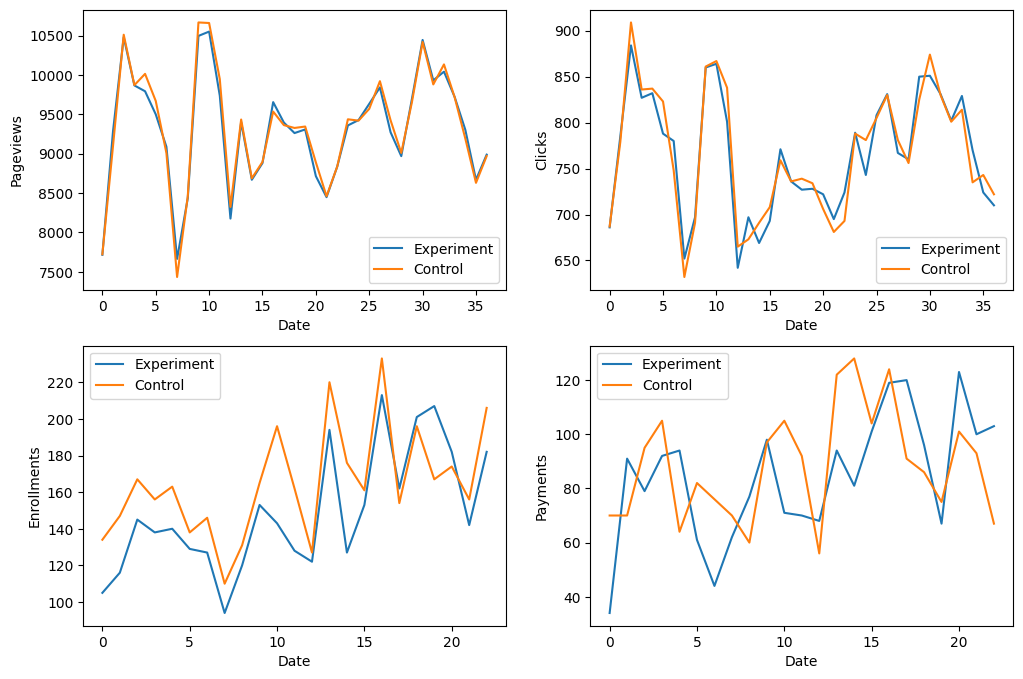

In [ ]:
figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
y_col = 'Pageviews'
compare_experiment_and_control(y_col)

plt.subplot(2, 2, 2)
y_col = 'Clicks'
compare_experiment_and_control(y_col)

plt.subplot(2, 2, 3)
y_col = 'Enrollments'
compare_experiment_and_control(y_col)

plt.subplot(2, 2, 4)
y_col = 'Payments'
compare_experiment_and_control(y_col)

Key observations:
* The number of data points for pageviews and clicks is greater than enrollments and payments. This means there are some null observations/missing values in the enrollments and payments columns. We will drop these rows in our downstream analysis.
* From plot #3, we see that the number of enrollments/user-ids for control (orange) seems to be higher than experiment (blue).

In [ ]:
experiment.tail()

,Date,Pageviews,Clicks,Enrollments,Payments
32,"Wed, Nov 12",10042,802,NaN,NaN
33,"Thu, Nov 13",9721,829,NaN,NaN
34,"Fri, Nov 14",9304,770,NaN,NaN
35,"Sat, Nov 15",8668,724,NaN,NaN
36,"Sun, Nov 16",8988,710,NaN,NaN


In [ ]:
def compare_distribution(y_col):
  plt.hist(experiment[y_col], label = 'Experiment', alpha = 0.5)
  plt.hist(control[y_col], label = 'Control', alpha = 0.5)
  plt.xlabel(y_col)
  plt.ylabel('Counts')
  plt.legend()

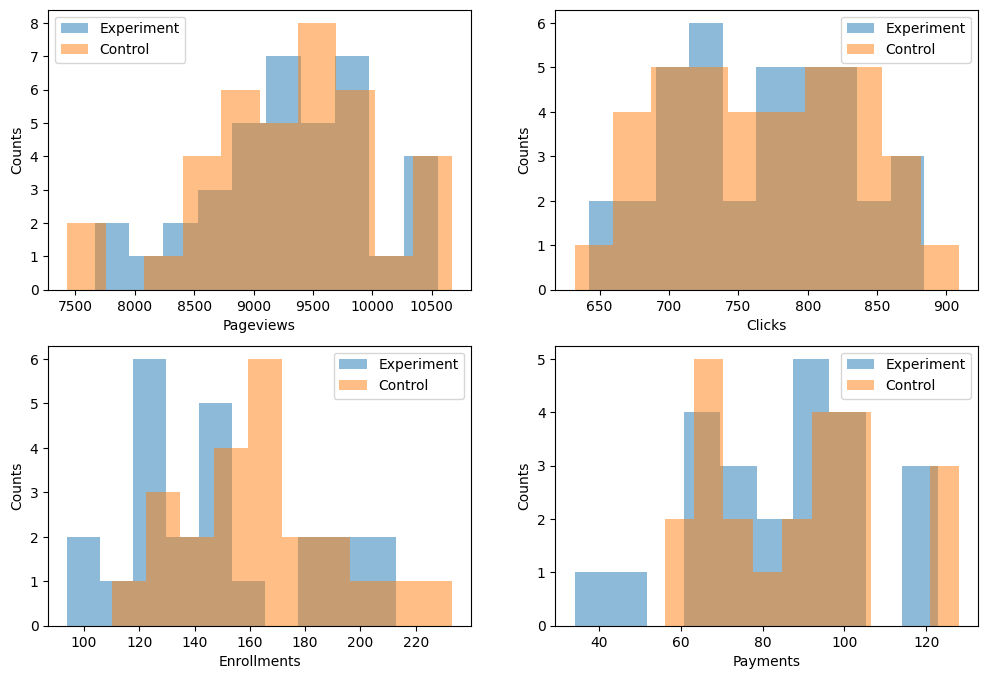

In [ ]:
figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
y_col = 'Pageviews'
compare_distribution(y_col)

plt.subplot(2, 2, 2)
y_col = 'Clicks'
compare_distribution(y_col)

plt.subplot(2, 2, 3)
y_col = 'Enrollments'
compare_distribution(y_col)

plt.subplot(2, 2, 4)
y_col = 'Payments'
compare_distribution(y_col)

Key observations:
* Again from plot #3, we notice that the peak of the distribution for enrollments in control (orange) is higher than experiment (blue).

## Sanity checks

#### Invariant metrics
* n_cookies
* n_clicks
* click through probability

#### Key takeaways
In this section, we verify that our invariant metrics are truely the same across the two groups. We find that all three of the invariant metrics are invariant. Therefore, the data passes the sanity checks.

In [ ]:
experiment = experiment.dropna()
control = control.dropna()
n_cookies_expt, n_cookies_ctrl = experiment['Pageviews'].sum(), control['Pageviews'].sum()
n_clicks_expt, n_clicks_ctrl = experiment['Clicks'].sum(), control['Clicks'].sum()
n_enroll_expt, n_enroll_ctrl = experiment['Enrollments'].sum(), control['Enrollments'].sum()
n_payments_expt, n_payments_ctrl = experiment['Payments'].sum(), control['Payments'].sum()
n_cookies = n_cookies_expt + n_cookies_ctrl
n_clicks = n_clicks_expt + n_clicks_ctrl
n_enroll = n_enroll_expt + n_enroll_ctrl
n_payments = n_payments_expt + n_payments_ctrl

In [ ]:
p_expt, p_ctrl = 0.5, 0.5
std_err_cookies = np.sqrt(p_expt*p_ctrl/n_cookies)
std_err_clicks = np.sqrt(p_expt*p_ctrl/n_clicks)
std_err_enroll = np.sqrt(p_expt*p_ctrl/n_enroll)

alpha = 0.05
z_alpha = stats.norm.ppf(1 - alpha/2)
margin_of_error_cookies = z_alpha*std_err_cookies
margin_of_error_clicks = z_alpha*std_err_clicks

confidence_interval_cookies = (round(p_ctrl - margin_of_error_cookies, 4), round(p_ctrl + margin_of_error_cookies, 4))
confidence_interval_clicks = (round(p_ctrl - margin_of_error_clicks, 4), round(p_ctrl + margin_of_error_clicks, 4))

print(f'Confidence interval for cookies: {confidence_interval_cookies}', f'Observed frequency of control: {round(n_cookies_ctrl/n_cookies, 4)}')
print(f'Confidence interval for clicks: {confidence_interval_clicks}', f'Observed frequency of control: {round(n_clicks_ctrl/n_clicks, 4)}')

Confidence interval for cookies: (0.4985, 0.5015) Observed frequency of control: 0.5009
Confidence interval for clicks: (0.4947, 0.5053) Observed frequency of control: 0.5005


Key observation:
* The observed number of cookies and clicks for the control group lie within the confidence intervals and therefore equivalent between the two groups.

In [ ]:
ctp_expt, ctp_ctrl = n_clicks_expt/n_cookies_expt, n_clicks_ctrl/n_cookies_ctrl

In [ ]:
ctp_diff = ctp_expt - ctp_ctrl

In [ ]:
ctp_pool = (n_clicks_expt + n_clicks_ctrl)/n_cookies

In [ ]:
ctp_std_err = np.sqrt(ctp_pool*(1 - ctp_pool)*(1/n_cookies_expt + 1/n_cookies_ctrl))

In [ ]:
alpha = 0.05
z_alpha = stats.norm.ppf(1 - alpha/2)
ctp_CI = (round(-z_alpha*ctp_std_err, 4), round(z_alpha*ctp_std_err, 4))

In [ ]:
def plot_effect_size(diff, CI, min_diff, title):
    plt.vlines(x=-min_diff, ymin = 0.49, ymax = 0.51, color='r', linestyle='--', label = 'd_min')
    plt.vlines(x=min_diff,  ymin = 0.49, ymax = 0.51, color='r', linestyle='--')
    plt.vlines(x = 0.,  ymin = 0.49, ymax = 0.51, label = 'No observed difference', linestyle = '--', color = 'black')
    plt.hlines(y = 0.5, xmin = diff + CI[0], xmax = diff + CI[1], color='b', label = 'Confidence Interval')
    plt.plot(diff, 0.5, marker = 'o', color = 'b')
    plt.yticks([])
    plt.legend()
    plt.title(title)
    print(f'Confidence Interval: ({round(diff + CI[0], 4)}, {round(diff + CI[1], 4)})\n')

Confidence Interval: (-0.0014, 0.0018)



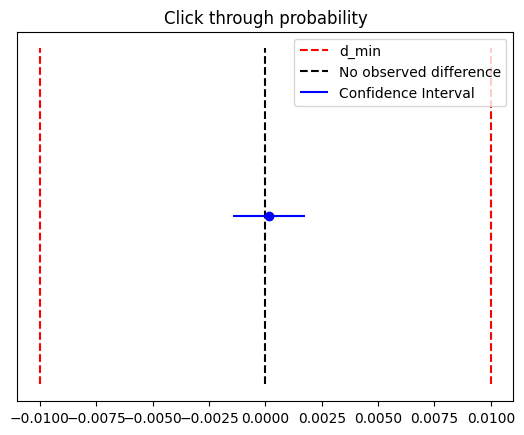

In [ ]:
plot_effect_size(ctp_diff, ctp_CI, min_diff['CTP'], 'Click through probability')

Key observation:
* The confidence interval for the difference between click-through-probability (CTP) in experiment vs. control includes zero and therefore the CTP is equivalent.

## Evaluation metrics
* n_enrollments
* Gross conversion
* Net conversion
* Retention

#### Key takeaways:

In this section, we compare the evaluation metrics across the experiment and control groups. We make the following observations:
* The number of enrollments in the control group is higher than in the experiment verifying our earlier observation about meeting one of the objectives of the AB test which was reducing the number of frustrated students who drop out before finishing and therefore enhancing user experience.
* The gross conversion rate defined as the fraction of users who enroll after clicking is lower for experiment than the control. The difference is both statistically and practically significant.
* The retention rate defined as the fraction of users who pay after enrolling is higher for experiment than control. Even though the difference is not practically significant, it is statistically significant. This suggests that more users who enroll are willing to pay in the experiment group than in the control group.
* The net conversion rate defined as the fraction of users who pay after clicking is the same for both groups. The difference is both statistically and practically insignificant.

The conclusion from the analysis of evaluation metrics is that even though less users in the experiment group enroll in the course after clicking, the rate of payment is higher. Therefore, the change in the course overview page does make a positive difference and enhances user experience. Note that the net conversion rate across the two groups stays the same and therefore revenue generated does not change.  

In [ ]:
margin_of_error_enroll = z_alpha*std_err_enroll
confidence_interval_enroll = (round(p_ctrl - margin_of_error_enroll, 4), round(p_ctrl + margin_of_error_enroll, 4))
print(f'Confidence interval for enrollments: {confidence_interval_enroll}', f'Observed frequency of control: {round(n_enroll_ctrl/n_enroll, 4)}')

Confidence interval for enrollments: (0.4885, 0.5115) Observed frequency of control: 0.5251


In [ ]:
gross_conversion_expt, gross_conversion_ctrl = n_enroll_expt/n_clicks_expt, n_enroll_ctrl/n_clicks_ctrl
retention_expt, retention_ctrl = n_payments_expt/n_enroll_expt, n_payments_ctrl/n_enroll_ctrl
net_conversion_expt, net_conversion_ctrl = n_payments_expt/n_clicks_expt, n_payments_ctrl/n_clicks_ctrl

In [ ]:
gross_conversion_diff = gross_conversion_expt - gross_conversion_ctrl
retention_diff = retention_expt - retention_ctrl
net_conversion_diff = net_conversion_expt - net_conversion_ctrl

In [ ]:
gross_conversion_pool = (n_enroll_expt + n_enroll_ctrl)/n_clicks
retention_pool = (n_payments_expt + n_payments_ctrl)/n_enroll
net_conversion_pool = (n_payments_expt + n_payments_ctrl)/n_clicks

In [ ]:
gross_conversion_std_err = np.sqrt(gross_conversion_pool*(1 - gross_conversion_pool)*(1/n_clicks_expt + 1/n_clicks_ctrl))
retention_std_err = np.sqrt(retention_pool*(1 - retention_pool)*(1/n_enroll_expt + 1/n_enroll_ctrl))
net_conversion_std_err = np.sqrt(net_conversion_pool*(1 - net_conversion_pool)*(1/n_clicks_expt + 1/n_clicks_ctrl))

In [ ]:
gross_conversion_CI = (round(-z_alpha*gross_conversion_std_err, 4), round(z_alpha*gross_conversion_std_err, 4))
retention_CI = (round(-z_alpha*retention_std_err, 4), round(z_alpha*retention_std_err, 4))
net_conversion_CI = (round(-z_alpha*net_conversion_std_err, 4), round(z_alpha*net_conversion_std_err, 4))

Confidence Interval: (-0.0292, -0.012)



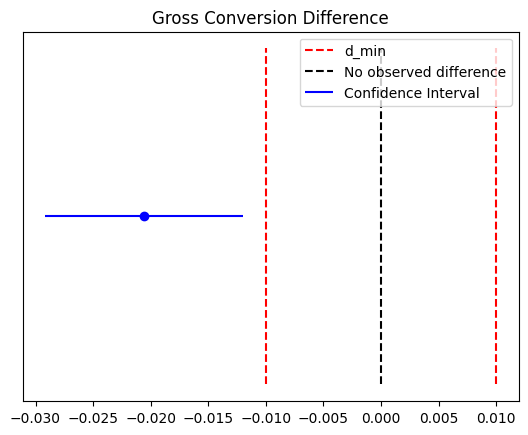

In [ ]:
plot_effect_size(gross_conversion_diff, gross_conversion_CI, min_diff["Gross_conversion"], 'Gross Conversion Difference')

Confidence Interval: (0.0081, 0.0541)



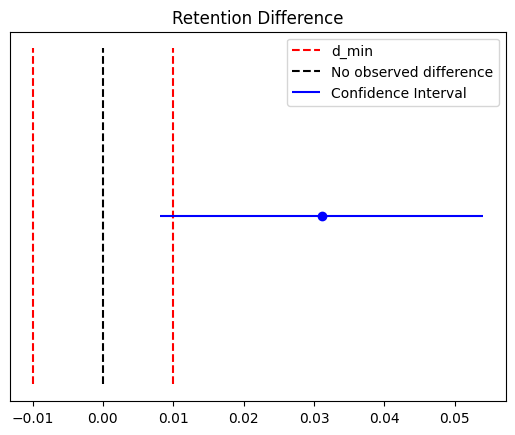

In [ ]:
plot_effect_size(retention_diff, retention_CI, min_diff["Retention"], 'Retention Difference')

Confidence Interval: (-0.0116, 0.0018)



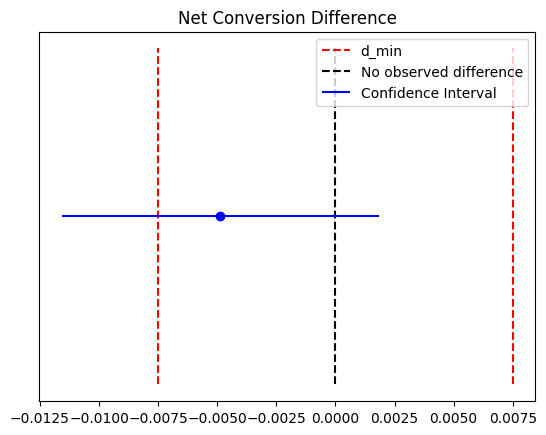

In [ ]:
plot_effect_size(net_conversion_diff, net_conversion_CI, min_diff["Net_conversion"], 'Net Conversion Difference')

## Sign tests

In this section, we do an additional sign test on the evaluation metrics to verify our observations from the previous section.

#### Key takeaways:
* We find that the binomial test for gross conversion is statistically significant further solidifying our previous observation that the gross conversion is lower for the experiment group.

In [ ]:
experiment.tail()

,Date,Pageviews,Clicks,Enrollments,Payments
18,"Wed, Oct 29",9262,727,201.0,96.0
19,"Thu, Oct 30",9308,728,207.0,67.0
20,"Fri, Oct 31",8715,722,182.0,123.0
21,"Sat, Nov 1",8448,695,142.0,100.0
22,"Sun, Nov 2",8836,724,182.0,103.0


In [ ]:
control.tail()

,Date,Pageviews,Clicks,Enrollments,Payments
18,"Wed, Oct 29",9327,739,196.0,86.0
19,"Thu, Oct 30",9345,734,167.0,75.0
20,"Fri, Oct 31",8890,706,174.0,101.0
21,"Sat, Nov 1",8460,681,156.0,93.0
22,"Sun, Nov 2",8836,693,206.0,67.0


In [ ]:
experiment['Gross_conversion'] = experiment['Enrollments']/experiment['Clicks']
experiment['Retention'] = experiment['Payments']/experiment['Enrollments']
experiment['Net_conversion'] = experiment['Payments']/experiment['Clicks']

In [ ]:
control['Gross_conversion'] = control['Enrollments']/control['Clicks']
control['Retention'] = control['Payments']/control['Enrollments']
control['Net_conversion'] = control['Payments']/control['Clicks']

In [ ]:
experiment.head()

,Date,Pageviews,Clicks,Enrollments,Payments,Gross_conversion,Retention,Net_conversion
0,"Sat, Oct 11",7716,686,105.0,34.0,0.153061,0.323810,0.049563
1,"Sun, Oct 12",9288,785,116.0,91.0,0.147771,0.784483,0.115924
2,"Mon, Oct 13",10480,884,145.0,79.0,0.164027,0.544828,0.089367
3,"Tue, Oct 14",9867,827,138.0,92.0,0.166868,0.666667,0.111245
4,"Wed, Oct 15",9793,832,140.0,94.0,0.168269,0.671429,0.112981


In [ ]:
from scipy.stats import binomtest

In [ ]:
gross_conversion_d = experiment['Gross_conversion'] - control['Gross_conversion']
retention_d = experiment['Retention'] - control['Retention']
net_conversion_d = experiment['Net_conversion'] - control['Net_conversion']

In [ ]:
res = binomtest(sum(gross_conversion_d > 0), len(gross_conversion_d))
print('Gross Conversion')
print(f'Number of successes: {sum(gross_conversion_d > 0)}')
print('Binomial statistic:', round(res.statistic, 4))
print('p-value:', round(res.pvalue, 4))

Gross Conversion
Number of successes: 4
Binomial statistic: 0.1739
p-value: 0.0026


Key observation:

* Gross conversion in experiment is lower than the control.

In [ ]:
res = binomtest(sum(retention_d > 0), len(retention_d))
print('Retention')
print('Binomial statistic:', round(res.statistic, 4))
print('p-value:', round(res.pvalue, 4))

Retention
Binomial statistic: 0.5652
p-value: 0.6776


Key observation:
* For retention, the binomial test is statistically insignificant whereas the overall difference is significant from the previous section.

Let's plot the daily variation of the retention rate and compare the experiment and control for further analysis.

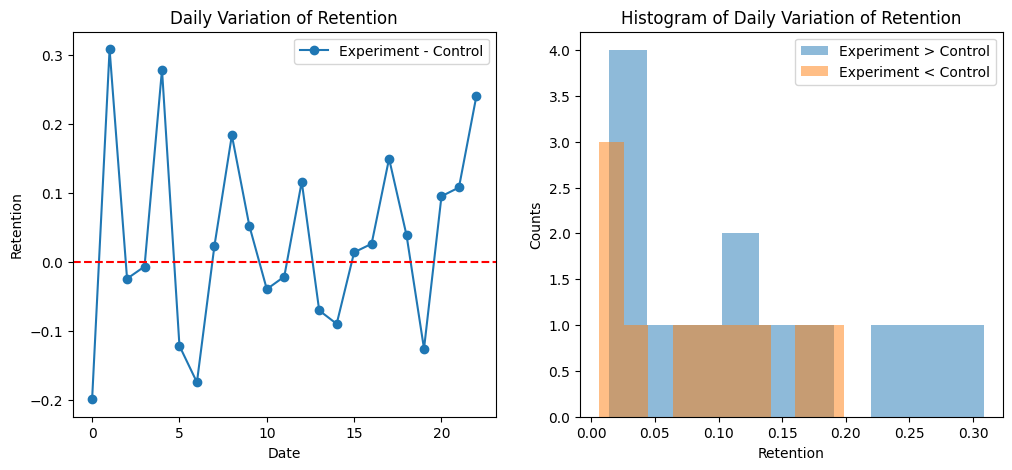

In [ ]:
figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.plot(retention_d, marker = 'o', label = 'Experiment - Control')
plt.xlabel('Date')
plt.ylabel('Retention')
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.title('Daily Variation of Retention')
plt.legend();

plt.subplot(1,2,2)
plt.hist(retention_d[retention_d > 0], label = 'Experiment > Control', alpha = 0.5)
plt.hist(abs(retention_d[retention_d < 0]), label = 'Experiment < Control', alpha = 0.5)
plt.xlabel('Retention')
plt.ylabel('Counts')
plt.title('Histogram of Daily Variation of Retention')
plt.legend();

Key observation:

* Even though the number of days the retention rate being greater for experiment is statistically insignificant, when it is greater than control, the magnitude is much larger. Therefore, the retention rate across the duration of the AB test is higher for experiment.

In [ ]:
res = binomtest(sum(net_conversion_d > 0), len(net_conversion_d))
print('Net Conversion')
print('Binomial statistic:', round(res.statistic, 4))
print('p-value:', round(res.pvalue, 4))

Net Conversion
Binomial statistic: 0.4348
p-value: 0.6776


## Recommendation

* In the end, we would recommend the team to launch this change because it enhances user experience without reducing the revenue generated.
* We would also recommend the team to conduct another experiment where they track the daily number of users who reach the end of a course. If more users in the experiment group finish the course before or after the trial, it would improve coaches' capacity to support students who are likely to complete the course.